# Optimal transport and Wasserstein gradient illustration

This notebook creates a two-panel figure: an optimal transport map on the left and a Wasserstein gradient defined with respect to an OT geodesic on the right.

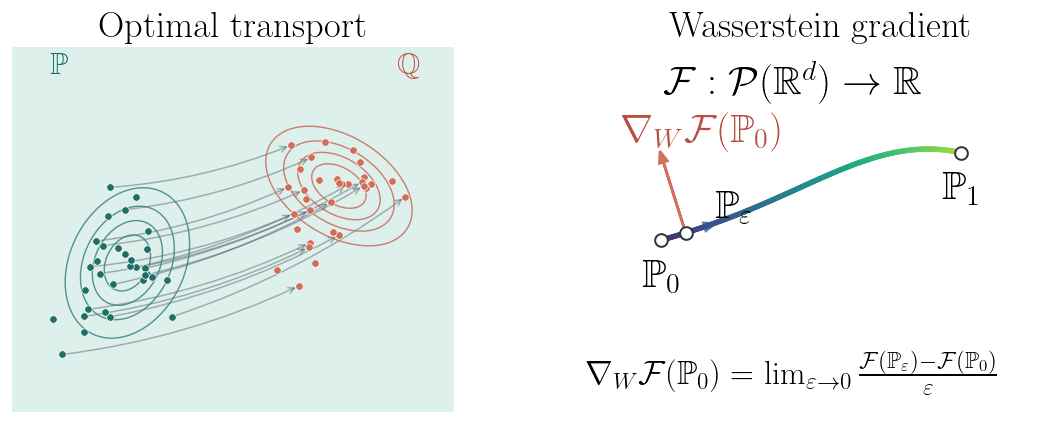

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from matplotlib.collections import LineCollection

plt.rcParams.update({
    "font.family": "DejaVu Serif",
    "axes.titlesize": 22,
    "axes.labelsize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 120,
})
plt.rc("text", usetex=True)
plt.rc("text.latex", preamble=r"\usepackage{amsmath, amssymb, amsfonts}")

rng = np.random.default_rng(7)

def blob(center, cov, n):
    return rng.multivariate_normal(center, cov, n)

def density(x, y, mean, cov):
    xy = np.stack([x - mean[0], y - mean[1]], axis=-1)
    inv_cov = np.linalg.inv(cov)
    exponent = np.einsum("...i,ij,...j->...", xy, inv_cov, xy)
    return np.exp(-0.5 * exponent)

source_mean = np.array([-1.15, -0.35])
target_mean = np.array([1.05, 0.45])
source_cov = np.array([[0.13, 0.04], [0.04, 0.19]])
target_cov = np.array([[0.18, -0.06], [-0.06, 0.12]])

source = blob(source_mean, source_cov, 32)
theta = np.deg2rad(28)
scale = np.array([[1.28, 0.0], [0.0, 0.78]])
rot = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
target = (source - source_mean) @ scale @ rot.T + target_mean
target += rng.normal(0, 0.035, target.shape)

grid = np.linspace(-2.35, 2.25, 220)
X, Y = np.meshgrid(grid, grid)
source_density = density(X, Y, source_mean, source_cov)
target_density = density(X, Y, target_mean, target_cov)

fig, axs = plt.subplots(1, 2, figsize=(10.2, 3.5), constrained_layout=False)
fig.subplots_adjust(left=0.035, right=0.985, bottom=0.05, top=0.92, wspace=0.02)

axs[0].contourf(X, Y, source_density, levels=10, colors=["#dcefeb"], alpha=0.92)
axs[0].contour(X, Y, source_density, levels=5, colors="#3a857f", linewidths=0.85, alpha=0.85)
axs[0].contour(X, Y, target_density, levels=5, colors="#c96f5f", linewidths=0.85, alpha=0.88)

for idx in np.linspace(0, len(source) - 1, 15, dtype=int):
    start = source[idx]
    end = target[idx]
    arrow = FancyArrowPatch(
        start, end, arrowstyle="->", mutation_scale=9,
        linewidth=0.9, color="#4e5960", alpha=0.45,
        connectionstyle="arc3,rad=0.08"
    )
    axs[0].add_patch(arrow)

axs[0].scatter(source[:, 0], source[:, 1], s=20, c="#1e6f68", edgecolors="white", linewidths=0.4, zorder=3)
axs[0].scatter(target[:, 0], target[:, 1], s=20, c="#cf6f5a", edgecolors="white", linewidths=0.4, zorder=3)
axs[0].text(-1.95, 1.62, r"$\mathbb{P}$", color="#1e6f68", fontsize=36)
axs[0].text(1.65, 1.62, r"$\mathbb{Q}$", color="#b95c4b", fontsize=36)
axs[0].set_title("Optimal transport")
axs[0].set_xlim(-2.35, 2.25)
axs[0].set_ylim(-1.9, 1.9)

t = np.linspace(0.0, 0.72, 220)
curve_x0 = -1.58
curve_speed = 4.0
curve_x = curve_x0 + curve_speed * t
curve_y = 0.68 * np.sin(np.pi * (t - 0.05)) - 0.15 * np.sin(2 * np.pi * t)
points = np.column_stack([curve_x, curve_y])
segments = np.stack([points[:-1], points[1:]], axis=1)
colors = plt.cm.viridis(np.linspace(0.12, 0.86, len(segments)))
axs[1].add_collection(LineCollection(segments, colors=colors, linewidths=3.2, capstyle="round"))

for tau, label, dx, dy in [(0.0, r"$\mathbb{P}_{0}$", 0.0, -0.34), (0.06, r"$\mathbb{P}_{\varepsilon}$", 0.46, 0.24), (0.72, r"$\mathbb{P}_{1}$", 0.0, -0.34)]:
    x = curve_x0 + curve_speed * tau
    y = 0.68 * np.sin(np.pi * (tau - 0.05)) - 0.15 * np.sin(2 * np.pi * tau)
    axs[1].scatter([x], [y], s=58, c="white", edgecolors="#2d3740", linewidths=1.2, zorder=4)
    axs[1].text(x + dx, y + dy, label, ha="center", va="center", fontsize=24)

tau = 0.06
x = curve_x0 + curve_speed * tau
y = 0.68 * np.sin(np.pi * (tau - 0.05)) - 0.15 * np.sin(2 * np.pi * tau)
dx_dt = curve_speed
dy_dt = 0.68 * np.pi * np.cos(np.pi * (tau - 0.05)) - 0.30 * np.pi * np.cos(2 * np.pi * tau)
tangent = np.array([dx_dt, dy_dt])
tangent = tangent / np.linalg.norm(tangent)
normal = np.array([-tangent[1], tangent[0]])

axs[1].arrow(x, y, 0.30 * tangent[0], 0.30 * tangent[1], head_width=0.08, head_length=0.11,
             length_includes_head=True, color="#4f7fba", linewidth=1.5)
axs[1].arrow(x, y, 0.82 * normal[0], 0.82 * normal[1], head_width=0.08, head_length=0.11,
             length_includes_head=True, color="#d36f5b", linewidth=1.6)
axs[1].text(x + 0.90 * tangent[0], y + 0.90 * tangent[1] - 0.10, r"", color="#315f9d", fontsize=12)
axs[1].text(-1.18, 0.94, r"$\nabla_W \mathcal{F}(\mathbb{P}_{0})$", color="#b94f42", fontsize=24, ha="center", va="center")

axs[1].text(-0.32, 1.42, r"$\mathcal{F}:\mathcal{P}(\mathbb{R}^d)\to\mathbb{R}$", fontsize=24, ha="center", va="center")
axs[1].text(-0.32, -1.36, r"$\nabla_W \mathcal{F}(\mathbb{P}_{0})=\lim_{\varepsilon\to0}\frac{\mathcal{F}(\mathbb{P}_{\varepsilon})-\mathcal{F}(\mathbb{P}_{0})}{\varepsilon}$", fontsize=20, ha="center", va="center")
axs[1].set_title("Wasserstein gradient")
axs[1].set_xlim(-2.15, 2.05)
axs[1].set_ylim(-1.75, 1.75)

for ax in axs:
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

save_path = "figures/ot_wasserstein_gradient_illustration.pdf"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
fig.savefig(save_path, bbox_inches="tight")
plt.show()